<a href="https://colab.research.google.com/github/pradeebavm-ai-20/Neural_Network_project/blob/main/Student_result_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- First 5 rows ---
   study_hours  attendance  previous_marks  assignment_score  result
0         7.74       84.20           34.34             77.03       0
1         4.39       93.18           62.08             97.24       1
2         8.59       95.26           39.03             55.96       1
3         6.97       70.22           40.66             59.76       1
4         0.94       71.22           74.26             86.85       0

--- Shape ---
(500, 5)

--- Data types ---
study_hours         float64
attendance          float64
previous_marks      float64
assignment_score    float64
result                int64
dtype: object

--- Descriptive statistics ---
       study_hours  attendance  previous_marks  assignment_score      result
count   500.000000  500.000000      500.000000         500.00000  500.000000
mean      4.956880   69.920520       65.320340          65.86922    0.550000
std       2.867881   17.795929       20.406533          20.11704    0.497992
min       0.050000   40.07

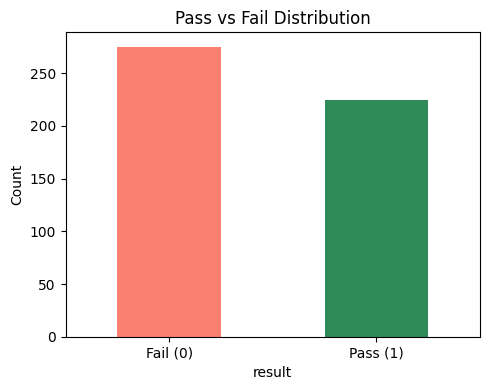

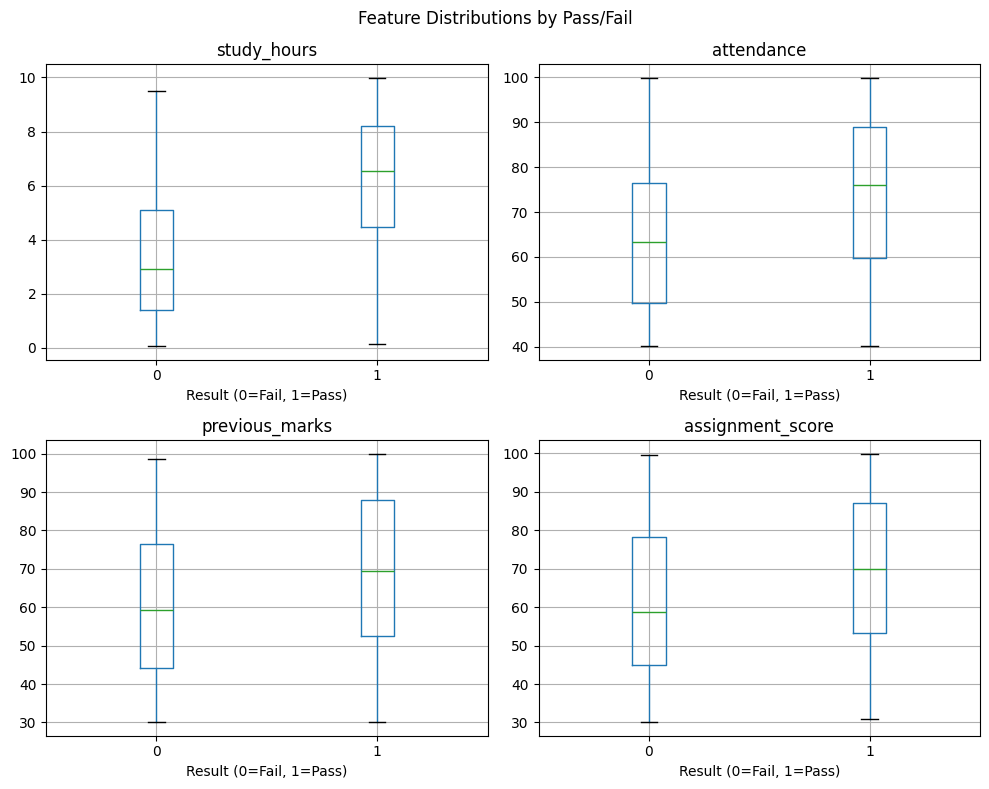

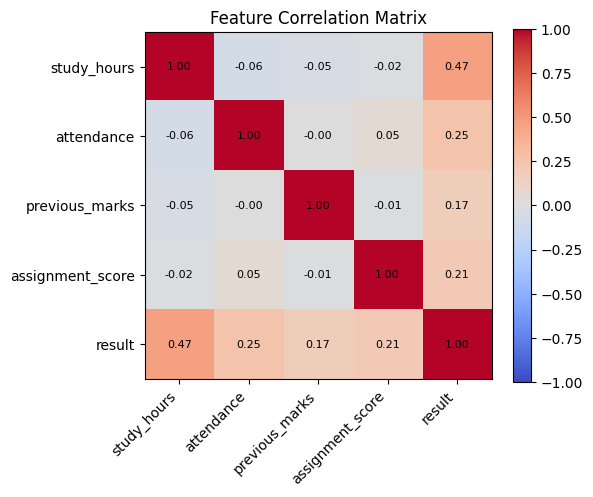


Saved plots: eda_class_distribution.png, eda_feature_boxplots.png, eda_correlation_heatmap.png

Train shape: (400, 4), Test shape: (100, 4)

--- Training ---
Epoch     1 | Loss: 0.68092
Epoch   200 | Loss: 0.47795
Epoch   400 | Loss: 0.45260
Epoch   600 | Loss: 0.45058
Epoch   800 | Loss: 0.44945
Epoch  1000 | Loss: 0.44885
Epoch  1200 | Loss: 0.44839
Epoch  1400 | Loss: 0.44783
Epoch  1600 | Loss: 0.44734
Epoch  1800 | Loss: 0.44639
Epoch  2000 | Loss: 0.44553


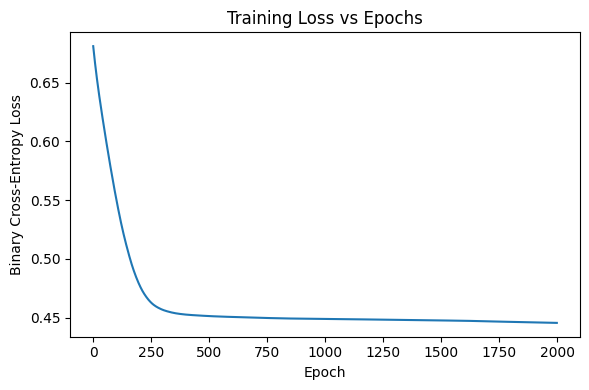


--- Evaluation on Test Set ---

Accuracy : 0.7800
Precision: 0.7846
Recall   : 0.8644
F1-score : 0.8226

Confusion Matrix ([[TN, FP], [FN, TP]]):
[[27 14]
 [ 8 51]]

--- New Student Predictions ---
Student 1 -> Probability: 0.9648, Prediction: Pass
Student 2 -> Probability: 0.0324, Prediction: Fail

Done.


In [ ]:
"""
Student Pass/Fail Classification Using a Neural Network from Scratch (NumPy only)
===================================================================================
A complete, beginner-friendly implementation. Every mathematical operation
(matrix multiplication, activations, loss, gradients, gradient descent) is
implemented manually using NumPy — no ML libraries used for the model itself.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Folder where all generated plots will be saved. Created automatically
# in whatever directory this script is run from (works on any machine).
os.makedirs("outputs", exist_ok=True)

# =====================================================================
# PART 1: DATASET GENERATION
# =====================================================================

def generate_dataset(n_samples=500, seed=42):
    """
    Creates a synthetic dataset of students with 4 features and a
    Pass/Fail label. The label is generated from a weighted combination
    of the features plus random noise, so the relationship is realistic
    but not perfectly deterministic (just like real life).
    """
    rng = np.random.default_rng(seed)

    study_hours = rng.uniform(0, 10, n_samples)          # hours/day
    attendance = rng.uniform(40, 100, n_samples)          # percentage
    previous_marks = rng.uniform(30, 100, n_samples)      # marks out of 100
    assignment_score = rng.uniform(30, 100, n_samples)    # marks out of 100

    # A "hidden" true score that determines Pass/Fail tendency.
    # Weights reflect a reasonable real-world intuition:
    # attendance & consistent study matter a lot; past performance too.
    true_score = (
        0.35 * study_hours * 10          # scale hours up (0-10 -> 0-100 range)
        + 0.30 * attendance
        + 0.20 * previous_marks
        + 0.15 * assignment_score
    )

    # Add random noise so the boundary isn't a perfectly sharp line
    noise = rng.normal(0, 12, n_samples)
    noisy_score = true_score + noise

    # Threshold: students above the median-ish cutoff pass
    threshold = np.percentile(noisy_score, 45)  # roughly 55% pass rate
    result = (noisy_score >= threshold).astype(int)

    df = pd.DataFrame({
        "study_hours": np.round(study_hours, 2),
        "attendance": np.round(attendance, 2),
        "previous_marks": np.round(previous_marks, 2),
        "assignment_score": np.round(assignment_score, 2),
        "result": result
    })
    return df


# =====================================================================
# PART 1: EDA (Exploratory Data Analysis)
# =====================================================================

def run_eda(df):
    print("\n--- First 5 rows ---")
    print(df.head())

    print("\n--- Shape ---")
    print(df.shape)

    print("\n--- Data types ---")
    print(df.dtypes)

    print("\n--- Descriptive statistics ---")
    print(df.describe())

    print("\n--- Missing values ---")
    print(df.isnull().sum())

    print("\n--- Duplicate rows ---")
    print(df.duplicated().sum())

    print("\n--- Pass vs Fail distribution ---")
    print(df["result"].value_counts())
    print(df["result"].value_counts(normalize=True) * 100)

    # Visualization 1: class distribution
    plt.figure(figsize=(5, 4))
    df["result"].value_counts().plot(kind="bar", color=["salmon", "seagreen"])
    plt.xticks([0, 1], ["Fail (0)", "Pass (1)"], rotation=0)
    plt.title("Pass vs Fail Distribution")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig("outputs/eda_class_distribution.png", dpi=120)
    plt.show()
    plt.close()

    # Visualization 2: feature relationships with result
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    features = ["study_hours", "attendance", "previous_marks", "assignment_score"]
    for ax, feat in zip(axes.ravel(), features):
        df.boxplot(column=feat, by="result", ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("Result (0=Fail, 1=Pass)")
    plt.suptitle("Feature Distributions by Pass/Fail")
    plt.tight_layout()
    plt.savefig("outputs/eda_feature_boxplots.png", dpi=120)
    plt.show()
    plt.close()

    # Visualization 3: correlation heatmap (manual, no seaborn)
    corr = df.corr()
    plt.figure(figsize=(6, 5))
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.title("Feature Correlation Matrix")
    plt.tight_layout()
    plt.savefig("outputs/eda_correlation_heatmap.png", dpi=120)
    plt.show()
    plt.close()

    print("\nSaved plots: eda_class_distribution.png, eda_feature_boxplots.png, "
          "eda_correlation_heatmap.png")


# =====================================================================
# PART 2: PREPROCESSING
# =====================================================================

def train_test_split_manual(X, y, test_size=0.2, seed=42):
    """
    Manually splits data into train/test sets without sklearn.
    Shuffles indices using a fixed seed for reproducibility.
    """
    rng = np.random.default_rng(seed)
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    rng.shuffle(indices)

    n_test = int(n_samples * test_size)
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    return X_train, X_test, y_train, y_test


def standardize(X_train, X_test):
    """
    Z-score standardization using ONLY training statistics.
    This avoids data leakage (test set must remain 'unseen').
    """
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    X_train_scaled = (X_train - mean) / std
    X_test_scaled = (X_test - mean) / std
    return X_train_scaled, X_test_scaled, mean, std


# =====================================================================
# PART 3-7: NEURAL NETWORK FROM SCRATCH
# =====================================================================

def custom_matmul(A, B):
    """
    Custom matrix multiplication implemented manually (no np.dot/np.matmul).
    A: (m, n), B: (n, p) -> result: (m, p)
    Uses NumPy only for elementwise multiply + sum (allowed basic ops).
    """
    m, n = A.shape
    n2, p = B.shape
    assert n == n2, f"Shape mismatch: {A.shape} vs {B.shape}"

    result = np.zeros((m, p))
    for i in range(p):
        # For each output column, multiply A by the i-th column of B
        # elementwise and sum across axis=1 -> this IS the dot product
        # of every row of A with column i of B, done manually.
        result[:, i] = np.sum(A * B[:, i], axis=1)
    return result


def relu(Z):
    """ReLU activation: max(0, Z). Introduces non-linearity."""
    return np.maximum(0, Z)


def relu_derivative(Z):
    """Derivative of ReLU: 1 where Z>0, else 0."""
    return (Z > 0).astype(float)


def sigmoid(Z):
    """Sigmoid squashes any real number into (0, 1) — a probability."""
    return 1 / (1 + np.exp(-Z))


def sigmoid_derivative(A):
    """Derivative of sigmoid, given the ALREADY-computed sigmoid output A."""
    return A * (1 - A)


def init_params(input_size=4, hidden_size=5, output_size=1, seed=42):
    """
    Initializes weights with small random values (breaks symmetry)
    and biases with zeros.
    """
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, 0.5, (input_size, hidden_size))
    b1 = np.zeros((1, hidden_size))
    W2 = rng.normal(0, 0.5, (hidden_size, output_size))
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2


def forward_propagation(X, W1, b1, W2, b2):
    """
    Computes the forward pass:
    Z1 = X.W1 + b1 ; A1 = ReLU(Z1)
    Z2 = A1.W2 + b2 ; A2 = Sigmoid(Z2)
    """
    Z1 = custom_matmul(X, W1) + b1
    A1 = relu(Z1)
    Z2 = custom_matmul(A1, W2) + b2
    A2 = sigmoid(Z2)
    cache = (Z1, A1, Z2, A2)
    return A2, cache


def compute_loss(y_true, y_pred, epsilon=1e-8):
    """
    Binary Cross-Entropy loss.
    y_true, y_pred shape: (m, 1)
    """
    m = y_true.shape[0]
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.mean(
        y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped)
    )
    return loss


def backward_propagation(X, y, cache, W2):
    """
    Computes gradients of the loss with respect to every parameter,
    using the chain rule, working backward from the output.
    """
    m = X.shape[0]
    Z1, A1, Z2, A2 = cache

    # Output layer gradients
    dZ2 = A2 - y                                  # (m, 1)
    dW2 = custom_matmul(A1.T, dZ2) / m            # (hidden, 1)
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m  # (1, 1)

    # Hidden layer gradients (chain rule back through W2 and ReLU)
    dA1 = custom_matmul(dZ2, W2.T)                # (m, hidden)
    dZ1 = dA1 * relu_derivative(Z1)               # (m, hidden)
    dW1 = custom_matmul(X.T, dZ1) / m             # (input, hidden)
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m  # (1, hidden)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads


def update_params(W1, b1, W2, b2, grads, learning_rate):
    """Gradient descent update: param = param - lr * gradient."""
    W1 = W1 - learning_rate * grads["dW1"]
    b1 = b1 - learning_rate * grads["db1"]
    W2 = W2 - learning_rate * grads["dW2"]
    b2 = b2 - learning_rate * grads["db2"]
    return W1, b1, W2, b2


def train_network(X_train, y_train, hidden_size=5, learning_rate=0.01,
                   epochs=2000, seed=42, print_every=200):
    """Full training loop."""
    input_size = X_train.shape[1]
    W1, b1, W2, b2 = init_params(input_size, hidden_size, 1, seed)

    loss_history = []
    for epoch in range(1, epochs + 1):
        A2, cache = forward_propagation(X_train, W1, b1, W2, b2)
        loss = compute_loss(y_train, A2)
        loss_history.append(loss)

        grads = backward_propagation(X_train, y_train, cache, W2)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, grads, learning_rate)

        if epoch % print_every == 0 or epoch == 1:
            print(f"Epoch {epoch:5d} | Loss: {loss:.5f}")

    params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return params, loss_history


# =====================================================================
# PART 9: EVALUATION (manual metrics, no sklearn)
# =====================================================================

def predict(X, params, threshold=0.5):
    A2, _ = forward_propagation(X, params["W1"], params["b1"], params["W2"], params["b2"])
    preds = (A2 >= threshold).astype(int)
    return preds, A2


def evaluate(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    accuracy = np.mean(y_true == y_pred)

    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

    confusion_matrix = np.array([[tn, fp], [fn, tp]])

    print(f"\nAccuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nConfusion Matrix ([[TN, FP], [FN, TP]]):")
    print(confusion_matrix)

    return {
        "accuracy": accuracy, "precision": precision,
        "recall": recall, "f1": f1, "confusion_matrix": confusion_matrix
    }


# =====================================================================
# PART 10: NEW STUDENT PREDICTION
# =====================================================================

def predict_student(study_hours, attendance, previous_marks, assignment_score,
                     params, mean, std):
    """
    Predicts Pass/Fail for a brand-new student using the SAME
    training mean/std used during training (no data leakage).
    """
    raw = np.array([[study_hours, attendance, previous_marks, assignment_score]])
    scaled = (raw - mean) / std
    prob, _ = forward_propagation(scaled, params["W1"], params["b1"], params["W2"], params["b2"])
    prob_value = float(prob[0, 0])
    label = "Pass" if prob_value >= 0.5 else "Fail"
    return prob_value, label


# =====================================================================
# MAIN — runs the full pipeline end-to-end
# =====================================================================

if __name__ == "__main__":
    # PART 1
    df = generate_dataset(n_samples=500, seed=42)
    run_eda(df)

    # PART 2
    X = df[["study_hours", "attendance", "previous_marks", "assignment_score"]].values
    y = df[["result"]].values.astype(float)

    X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.2, seed=42)
    X_train_scaled, X_test_scaled, mean, std = standardize(X_train, X_test)

    print(f"\nTrain shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")

    # PART 8: TRAIN
    print("\n--- Training ---")
    params, loss_history = train_network(
        X_train_scaled, y_train, hidden_size=5, learning_rate=0.05,
        epochs=2000, seed=42, print_every=200
    )

    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.title("Training Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.tight_layout()
    plt.savefig("outputs/training_loss.png", dpi=120)
    plt.show()
    plt.close()

    # PART 9: EVALUATE
    print("\n--- Evaluation on Test Set ---")
    test_preds, test_probs = predict(X_test_scaled, params)
    metrics = evaluate(y_test, test_preds)

    # PART 10: NEW STUDENT PREDICTIONS
    print("\n--- New Student Predictions ---")
    prob1, label1 = predict_student(8.0, 90, 75, 85, params, mean, std)
    print(f"Student 1 -> Probability: {prob1:.4f}, Prediction: {label1}")

    prob2, label2 = predict_student(2.0, 55, 40, 35, params, mean, std)
    print(f"Student 2 -> Probability: {prob2:.4f}, Prediction: {label2}")

    print("\nDone.")